In [2]:
# Import libraries

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) # Adjusts the configuration of the plots we will create

# Read in the data

df = pd.read_csv(r'D:\Users\JackyL\OneDrive\Documents\Data Analyst Project By Alex\Correlation in Python\movies.csv')

In [3]:
# Let's look at the data

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# Let's see if there is any missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [5]:
# Data types for our columns

df.dtypes

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object

In [6]:
# Change data type of columns

df['year'] = pd.to_numeric(df['year'], errors='coerce').fillna(0).astype('int64')
df['budget'] = pd.to_numeric(df['budget'], errors='coerce').fillna(0).astype('int64')
df['gross'] = pd.to_numeric(df['gross'], errors='coerce').fillna(0).astype('int64')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce').fillna(0).astype('int64')
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce').fillna(0).astype('int64')
df['score'] = pd.to_numeric(df['score'], errors='coerce').fillna(0).astype(float)

In [7]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,0,0,Cactus Blue Entertainment,90
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,0,Embi Productions,0
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",0.0,0,James Randall,James Randall,Christina Roz,United States,15000,0,NaN,120


In [8]:
# Create correct year column from existing 'released' column

df['yearcorrect'] = df['released'].astype(str).str.rsplit('(', n=1).str[0]
df['yearcorrect'] = df['yearcorrect'].str.split(',', n=1).str[1]
df['yearcorrect'] = pd.to_numeric(df['yearcorrect'], errors='coerce').fillna(0).astype('int64')

df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90,2020
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,0,0,Cactus Blue Entertainment,90,2020
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,0,Embi Productions,0,2020
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",0.0,0,James Randall,James Randall,Christina Roz,United States,15000,0,NaN,120,2020


In [9]:
# Order data by 'gross' in descending order

df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90,2020
641,Blame It on the Night,PG-13,Comedy,1984,"November 2, 1984 (United States)",5.1,172,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85,1984
7658,Black Wall Street Burning,R,Drama,2020,"February 7, 2020 (United States)",6.6,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78,2020
671,Flesh+Blood,R,Adventure,1985,"August 30, 1985 (United States)",6.7,17000,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126,1985


In [10]:
# Drop any duplicates

df['company'].drop_duplicates().sort_values(ascending=False)

7129                                thefyzz
5664                            micro_scope
6412               iDeal Partners Film Fund
4007                               i5 Films
6793                             i am OTHER
                       ...                 
3748                     1+2 Seisaku Iinkai
3024                        .406 Production
7525    "Weathering With You" Film Partners
4345        "DIA" Productions GmbH & Co. KG
408                                     NaN
Name: company, Length: 2386, dtype: str

<Axes: title={'center': 'budget'}, xlabel='genre'>

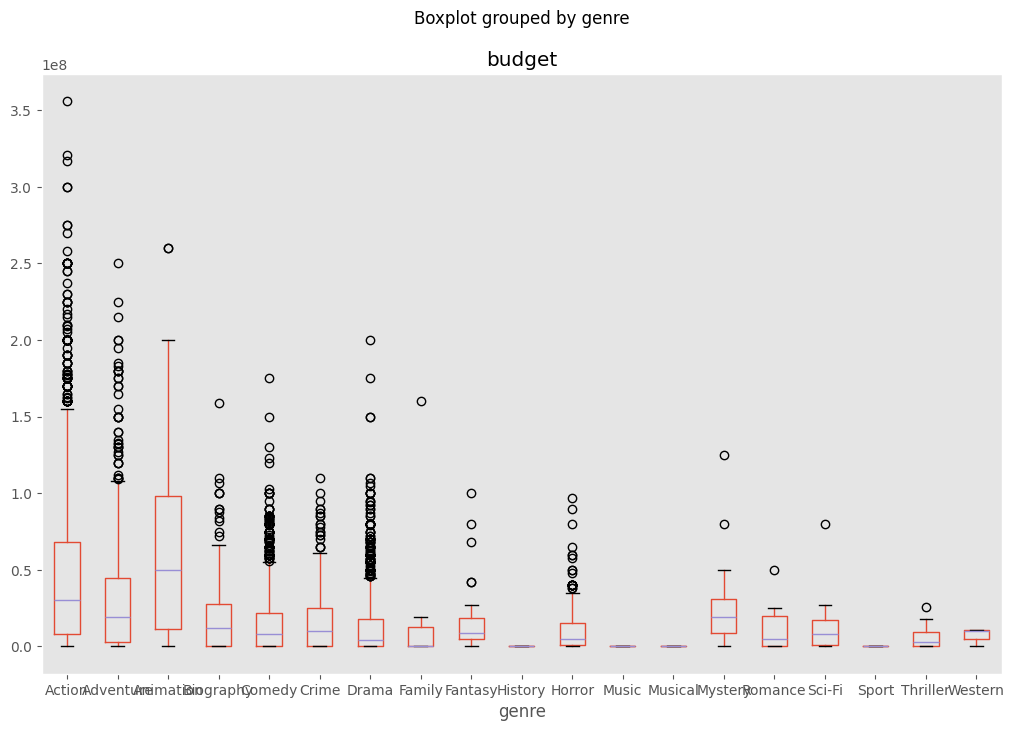

In [ ]:
# Are there any Outliers?

df.boxplot(by='genre', column=['budget'], grid=False)

C:\Users\JackyL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


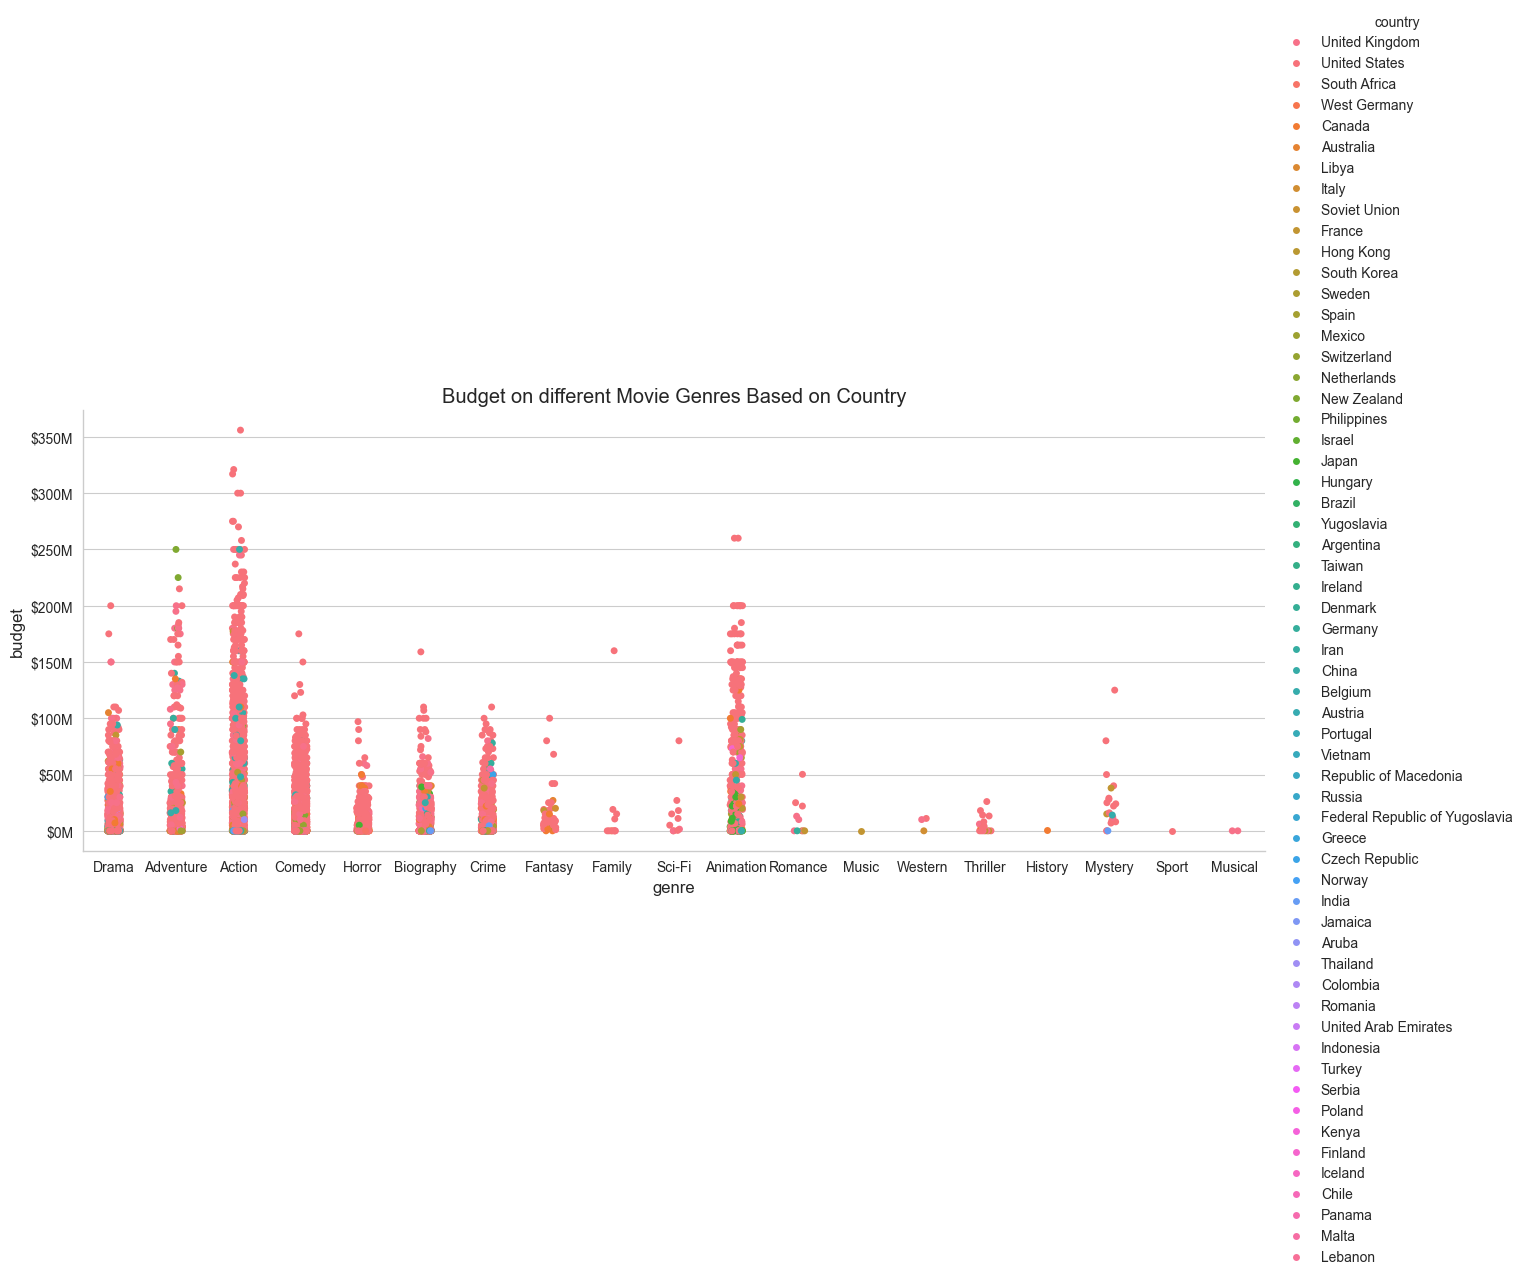

In [65]:
# Categorical plot with genre, budget, country

sns.catplot(data=df,x="genre",y="budget",hue="country",height=5, aspect=2.5)

# Define the formatter function
def format_func(value, tick_number):
    return f'${int(value / 1000000)}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

plt.title('Budget on different Movie Genres Based on Country')

plt.show()

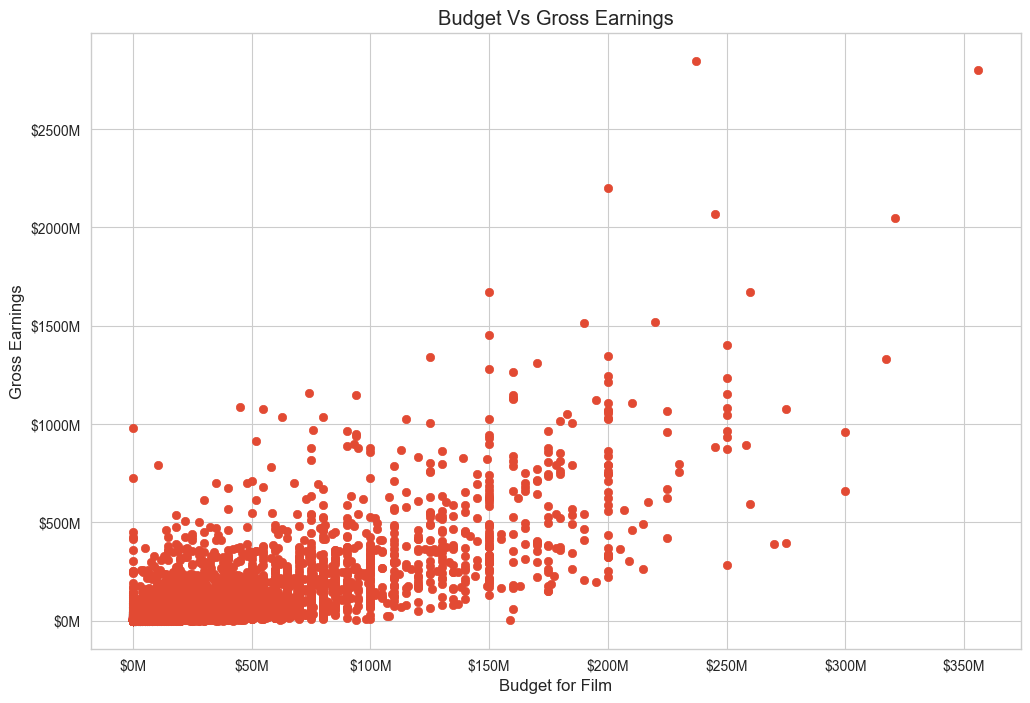

In [ ]:
# Scatter plot with budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])

# Define the formatter function
def format_func(value, tick_number):
    return f'${int(value / 1000000)}M'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

plt.title('Budget Vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')

plt.show()

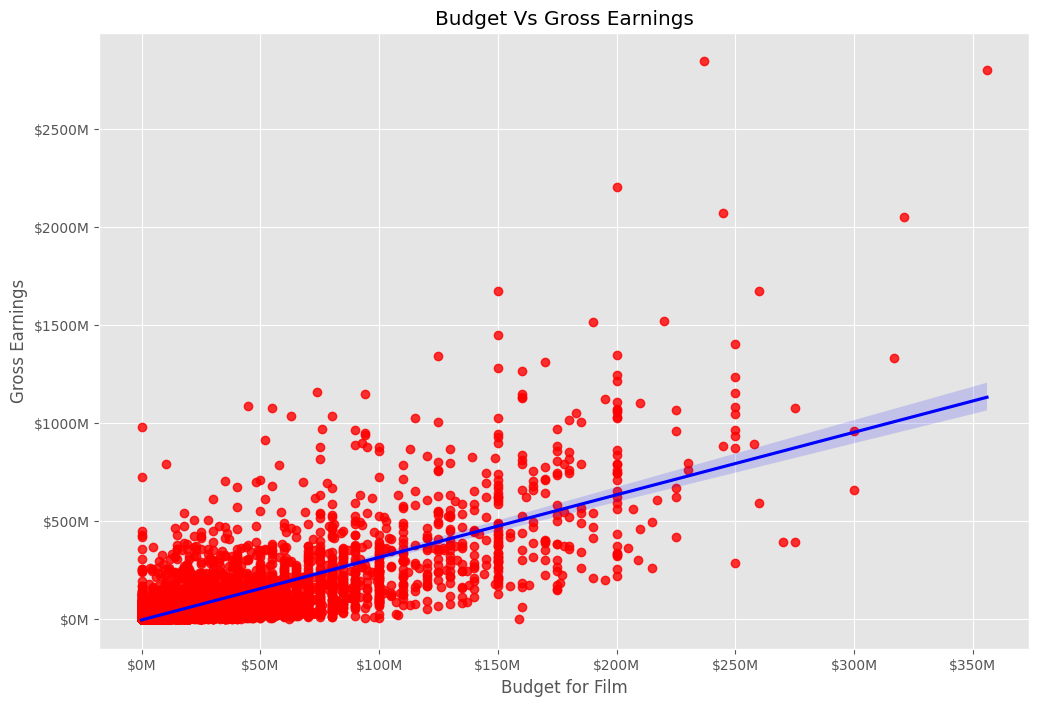

In [13]:
# Plot budget vs gross using seaborn

sns.regplot(x='budget', y='gross', data=df, scatter_kws={'color': 'red'}, line_kws={'color': 'blue'})


# Define the formatter function
def format_func(value, tick_number):
    return f'${int(value / 1000000)}M'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

plt.title('Budget Vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')

plt.show()


In [14]:
# Correlation Matrix between all numeric columns

df.corr(method='pearson',numeric_only=True)

,year,score,votes,budget,gross,runtime,yearcorrect
year,1.000000,0.092616,0.222427,0.309212,0.261900,0.116358,0.143738
score,0.092616,1.000000,0.407101,0.056863,0.186012,0.394564,0.001132
votes,0.222427,0.407101,1.000000,0.486931,0.632870,0.306984,0.056025
budget,0.309212,0.056863,0.486931,1.000000,0.750157,0.268372,0.073969
gross,0.261900,0.186012,0.632870,0.750157,1.000000,0.244339,0.056556
runtime,0.116358,0.394564,0.306984,0.268372,0.244339,1.000000,0.043666
yearcorrect,0.143738,0.001132,0.056025,0.073969,0.056556,0.043666,1.000000


In [15]:
df.corr(method='kendall',numeric_only=True)

,year,score,votes,budget,gross,runtime,yearcorrect
year,1.000000,0.066796,0.330410,0.209304,0.216595,0.096390,0.981147
score,0.066796,1.000000,0.300673,-0.004843,0.091331,0.283601,0.072270
votes,0.330410,0.300673,1.000000,0.439883,0.560449,0.197697,0.326376
budget,0.209304,-0.004843,0.439883,1.000000,0.541956,0.176184,0.203853
gross,0.216595,0.091331,0.560449,0.541956,1.000000,0.177429,0.211781
runtime,0.096390,0.283601,0.197697,0.176184,0.177429,1.000000,0.097288
yearcorrect,0.981147,0.072270,0.326376,0.203853,0.211781,0.097288,1.000000


In [16]:
df.corr(method='spearman', numeric_only=True)

,year,score,votes,budget,gross,runtime,yearcorrect
year,1.000000,0.097757,0.468107,0.291152,0.314681,0.141805,0.993504
score,0.097757,1.000000,0.428810,-0.007002,0.133564,0.399868,0.105865
votes,0.468107,0.428810,1.000000,0.604693,0.752550,0.289359,0.463283
budget,0.291152,-0.007002,0.604693,1.000000,0.716816,0.246941,0.282827
gross,0.314681,0.133564,0.752550,0.716816,1.000000,0.257478,0.306900
runtime,0.141805,0.399868,0.289359,0.246941,0.257478,1.000000,0.143385
yearcorrect,0.993504,0.105865,0.463283,0.282827,0.306900,0.143385,1.000000


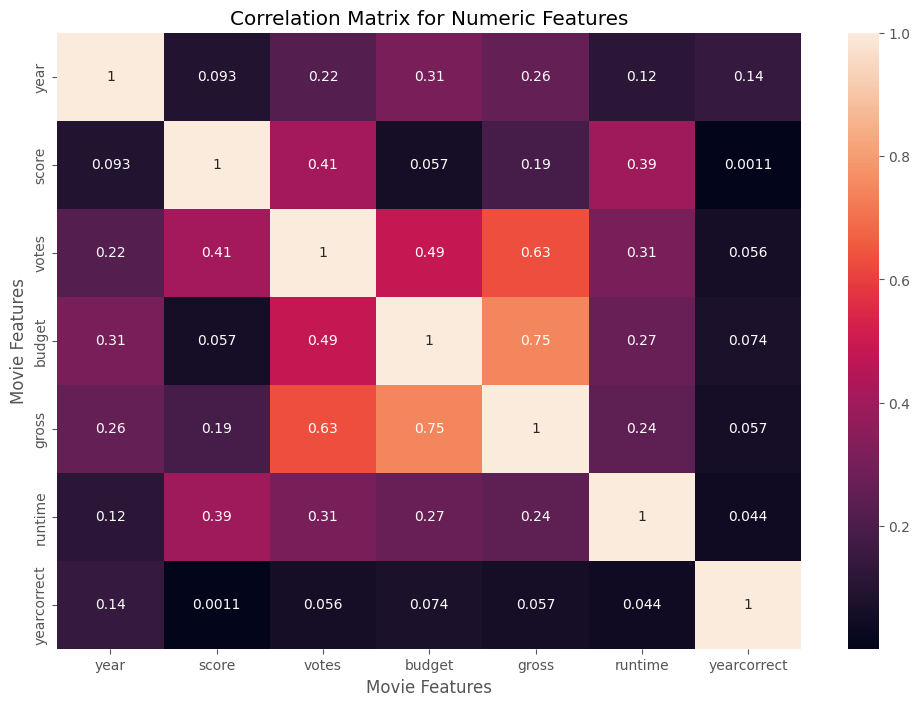

In [17]:
# high correlation between budget and gross

correlation_matrix = df.corr(method='pearson', numeric_only=True)

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation Matrix for Numeric Features")

plt.xlabel("Movie Features")

plt.ylabel("Movie Features")

plt.show()

In [18]:
df_numerized = df.copy()

for col_name in df_numerized.columns:
   if(df_numerized[col_name].dtype == 'str'):
     df_numerized[col_name] = df_numerized[col_name].astype('category')
     df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,6587,6,6,1980,1705,8.4,927000,2589,4014,1047,54,19000000,46998772,2319,146,1980
1,5573,6,1,1980,1492,5.8,65000,2269,1632,327,55,4500000,58853106,731,104,1980
2,5142,4,0,1980,1771,8.7,1200000,1111,2567,1745,55,18000000,538375067,1540,124,1980
3,286,4,4,1980,1492,7.7,221000,1301,2000,2246,55,3500000,83453539,1812,88,1980
4,1027,6,4,1980,1543,7.3,108000,1054,521,410,55,6000000,39846344,1777,98,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,-1,6,2020,2964,3.1,18,1500,2289,2421,55,7000,0,-1,90,2020
7664,1678,-1,4,2020,1107,4.7,36,774,2614,1886,55,0,0,539,90,2020
7665,4717,-1,6,2020,193,5.7,29,2061,2683,2040,55,58750,0,941,0,2020
7666,2843,-1,6,2020,2817,0.0,0,1184,1824,450,55,15000,0,-1,120,2020


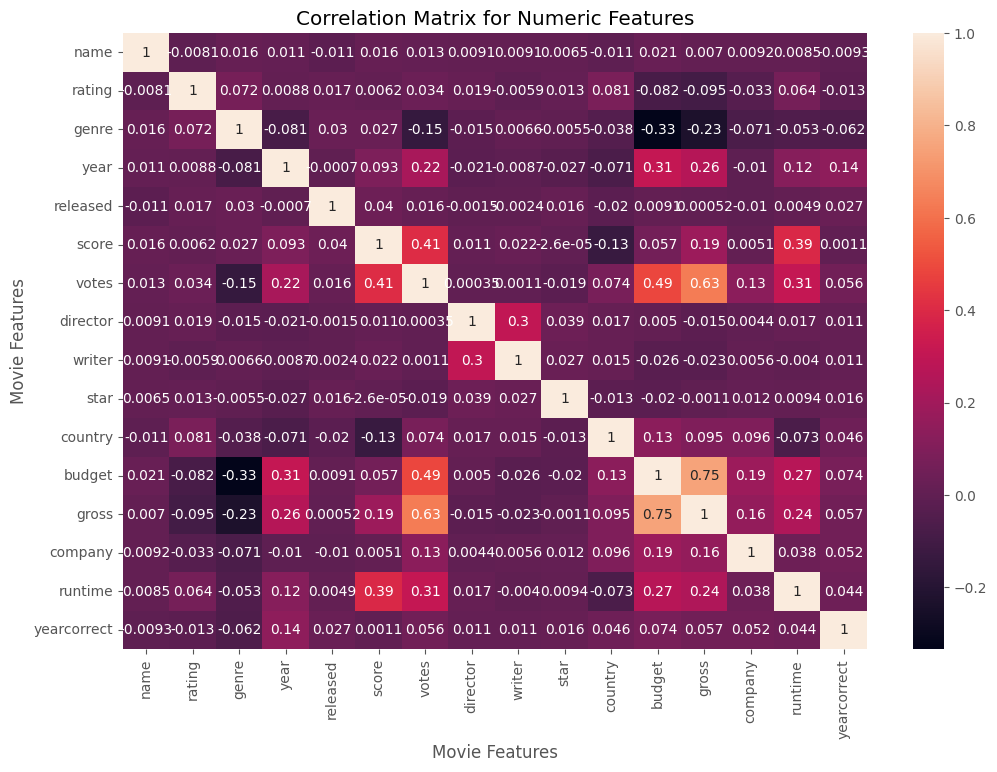

In [19]:
correlation_matrix_max = df_numerized.corr(method='pearson', numeric_only=True)

sns.heatmap(correlation_matrix_max, annot = True)

plt.title("Correlation Matrix for Numeric Features")

plt.xlabel("Movie Features")

plt.ylabel("Movie Features")

plt.show()

In [20]:
correlation_mat = df_numerized.corr()

corr_pairs = correlation_mat.unstack()

corr_pairs

name         name           1.000000
             rating        -0.008069
             genre          0.016355
             year           0.011453
             released      -0.011311
                              ...   
yearcorrect  budget         0.073969
             gross          0.056556
             company        0.051730
             runtime        0.043666
             yearcorrect    1.000000
Length: 256, dtype: float64

In [21]:
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

sorted_pairs

genre        budget        -0.334021
budget       genre         -0.334021
gross        genre         -0.234297
genre        gross         -0.234297
             votes         -0.145296
                              ...   
star         star           1.000000
company      company        1.000000
gross        gross          1.000000
runtime      runtime        1.000000
yearcorrect  yearcorrect    1.000000
Length: 256, dtype: float64

In [22]:
# We can now take a look at the ones that have a high correlation (> 0.5)

strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

strong_pairs

votes        gross          0.632870
gross        votes          0.632870
budget       gross          0.750157
gross        budget         0.750157
director     director       1.000000
votes        votes          1.000000
released     released       1.000000
score        score          1.000000
rating       rating         1.000000
name         name           1.000000
genre        genre          1.000000
year         year           1.000000
budget       budget         1.000000
country      country        1.000000
writer       writer         1.000000
star         star           1.000000
company      company        1.000000
gross        gross          1.000000
runtime      runtime        1.000000
yearcorrect  yearcorrect    1.000000
dtype: float64